# Data Science for Business - Subset selection on Ames Housing

*Session 5 · ISLP 6.1.1–6.1.3 (Algorithm 6.2)*

## Initialize notebook
Load required packages. Set up workspace, e.g., set theme for plotting and initialize the random number generator.

In [1]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
np.random.seed(42)
plt.style.use('fivethirtyeight')

## Problem description

Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence. With 76 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this dataset challenges you to predict the final price of each home. More: <https://www.kaggle.com/c/house-prices-advanced-regression-techniques>

## Load data

Load data from CSV file.

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/olivermueller/ds4b-2026/main/Session_05/ameshousing.csv')

In [4]:
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ThreeSsnPorch,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,20,RL,141,31770,Pave,none,IR1,Lvl,AllPub,Corner,...,0,0,0,none,0,5,2010,WD,Normal,215000
1,20,RH,80,11622,Pave,none,Reg,Lvl,AllPub,Inside,...,0,120,0,MnPrv,0,6,2010,WD,Normal,105000
2,20,RL,81,14267,Pave,none,IR1,Lvl,AllPub,Corner,...,0,0,0,none,12500,6,2010,WD,Normal,172000
3,20,RL,93,11160,Pave,none,Reg,Lvl,AllPub,Corner,...,0,0,0,none,0,4,2010,WD,Normal,244000
4,60,RL,74,13830,Pave,none,IR1,Lvl,AllPub,Inside,...,0,0,0,MnPrv,0,3,2010,WD,Normal,189900


In [5]:
data.shape

(2930, 77)

In [6]:
data.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', 'FirstFlrSF', 'SecondFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF',

## Prepare data

First, we will remove some columns that are not useful for our task.

In [7]:
data = data.drop(['YrSold', 'MoSold', 'SaleCondition', 'SaleType'], axis=1)

Next, we will split the data into predictors (*X*) and response (*y*) and into training (*X_train, y_train*) and test (*X_test, y_test*) sets.

In [8]:
X = data.drop("SalePrice", axis=1)
y = data["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Finally, we will do some feature engineering. It is important to use only information from the training set for feature engineering, and then mechanistically repeat these steps on the test set.

Typically, feature engineering depends strongly on the datatype of the variables. Hence, we will first determine which variables are categorical and which are numerical. Subsequently, we will transform these variables separately.

In [9]:
categorical_features = X_train.select_dtypes(include=['object', 'string']).columns
numerical_features = X_train.select_dtypes(exclude=['object', 'string']).columns

In [10]:
categorical_features

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'Fence'],
      dtype='str')

In [11]:
numerical_features

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', 'FirstFlrSF', 'SecondFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ThreeSsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal'],
      dtype='str')

The categorical variables must be transformed into numerical representations, e.g., by one-hot encoding them.

In [12]:
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(X_train[categorical_features])

X_train_cat = enc.transform(X_train[categorical_features])
X_test_cat = enc.transform(X_test[categorical_features])

X_train_cat = pd.DataFrame(X_train_cat, columns=enc.get_feature_names_out(categorical_features))
X_test_cat = pd.DataFrame(X_test_cat, columns=enc.get_feature_names_out(categorical_features))

In [13]:
X_train_cat.head()

,MSZoning_A(agr),MSZoning_C(all),MSZoning_FV,MSZoning_I(all),MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,...,GarageCond_TA,GarageCond_none,PavedDrive_N,PavedDrive_P,PavedDrive_Y,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_none
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


The numerical variables will be standardized, that is, we will subtract the mean and divide by the standard deviation. The scaler is fit on the training data only.

In [14]:
scaler = StandardScaler()
scaler.fit(X_train[numerical_features])

X_train_num = scaler.transform(X_train[numerical_features])
X_test_num = scaler.transform(X_test[numerical_features])

X_train_num = pd.DataFrame(X_train_num, columns=numerical_features)
X_test_num = pd.DataFrame(X_test_num, columns=numerical_features)

In [15]:
X_train_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ThreeSsnPorch,ScreenPorch,PoolArea,MiscVal
0,-0.871817,0.667826,0.033810,0.673941,-0.526415,0.181084,-0.381277,0.531409,-0.978369,-0.293998,...,0.614268,0.339813,0.047615,-0.753959,-0.695967,-0.369038,-0.098812,-0.286876,-0.067407,-0.09315
1,0.062906,-1.717704,2.307082,-0.766750,-0.526415,-0.115603,-0.814347,-0.569155,-0.427633,4.191480,...,-0.917482,0.339813,0.325180,3.139485,-0.695967,-0.369038,-0.098812,3.744734,-0.067407,-0.09315
2,0.763949,0.369635,-0.035514,-1.487095,-0.526415,-0.280430,-1.054941,-0.569155,-0.978369,-0.293998,...,-0.917482,0.339813,-0.032361,-0.753959,-0.695967,-0.369038,-0.098812,-0.286876,-0.067407,-0.09315
3,0.763949,0.071444,-0.363746,-1.487095,-0.526415,-0.708978,-1.632368,-0.569155,-0.978369,-0.293998,...,-0.917482,0.339813,-0.229950,-0.753959,-0.695967,-0.369038,-0.098812,-0.286876,-0.067407,-0.09315
4,3.100756,0.160901,-0.310697,-1.487095,0.378216,-1.664971,-1.632368,-0.569155,-0.978369,-0.293998,...,-0.917482,-2.337571,-2.205835,-0.753959,-0.695967,1.839369,-0.098812,-0.286876,-0.067407,-0.09315


Join categorical and numerical features. We standardize only the numerical features; the dummies are already 0/1.

In [16]:
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

In [17]:
X_train.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageCond_TA,GarageCond_none,PavedDrive_N,PavedDrive_P,PavedDrive_Y,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_none
0,-0.871817,0.667826,0.033810,0.673941,-0.526415,0.181084,-0.381277,0.531409,-0.978369,-0.293998,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.062906,-1.717704,2.307082,-0.766750,-0.526415,-0.115603,-0.814347,-0.569155,-0.427633,4.191480,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.763949,0.369635,-0.035514,-1.487095,-0.526415,-0.280430,-1.054941,-0.569155,-0.978369,-0.293998,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.763949,0.071444,-0.363746,-1.487095,-0.526415,-0.708978,-1.632368,-0.569155,-0.978369,-0.293998,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,3.100756,0.160901,-0.310697,-1.487095,0.378216,-1.664971,-1.632368,-0.569155,-0.978369,-0.293998,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [18]:
X_train.shape

(2344, 287)

## Stepwise (forward/backward) feature selection

*Best subset selection* (ISLP 6.1.1, Algorithm 6.1) would fit all $2^p$ possible models. With $p \approx 290$ predictors this is impossible (the book puts the practical limit at around 40 predictors). Stepwise selection (ISLP 6.1.2) is a greedy, computationally cheap alternative.

### Feature selection with pre-defined number of features

Forward stepwise selection (ISLP 6.1.2, Algorithm 6.2) starts with no predictors and greedily adds the predictor that improves the fit most. We use sklearn's `SequentialFeatureSelector`, which can do *forward* and *backward* selection.

Note a small difference to the book: sklearn evaluates each candidate within a step by 5-fold CV RMSE, whereas Algorithm 6.2 uses the training RSS (or $R^2$) within each step and uses Cp/BIC/adjusted $R^2$ or CV only to choose the number of predictors (ISLP 6.1.3).

In [19]:
lm = LinearRegression()
sfs_fwd = SequentialFeatureSelector(lm, n_features_to_select=3, direction='forward', scoring='neg_root_mean_squared_error', cv=5)
sfs_fwd.fit(X_train, y_train)

,estimator estimator: estimator instanceAn unfitted estimator.,LinearRegression()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",3
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'neg_root_mean_squared_error'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"cv cv: int, cross-validation generator or an iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](287,)","['MSSubClass','LotFrontage','LotArea',...,'Fence_MnPrv','Fence_MnWw', 'Fence_none']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,287
n_features_to_select_ n_features_to_select_: intThe number of features that were selected.,int64,np.int64(3)


Show the selected features. Note: The features are NOT listed in the order of their importance, but in the order they appear in the dataset!

In [20]:
sfs_fwd.get_feature_names_out()

array(['OverallQual', 'GrLivArea', 'BsmtQual_Ex'], dtype=object)

To see how well a model with these selected features performs, we train it on the full training data and evaluate it on the test data. CV on the training data chose the features; the test set is only used for this final evaluation.

In [21]:
mod_selected_features = LinearRegression().fit(X_train[sfs_fwd.get_feature_names_out()], y_train)
preds_selected_features = mod_selected_features.predict(X_test[sfs_fwd.get_feature_names_out()])
print(root_mean_squared_error(y_test, preds_selected_features))

39785.934228207014


### Choosing the number of features by cross-validation

So far, we simply decided to use 3 features. How many should we use? ISLP 6.1.3 recommends estimating the test error of the best model of each size $k$ by cross-validation **on the training data** and picking the size with the lowest CV error.

The loop below runs forward selection for $k = 1, \dots, 10$, computes the 5-fold CV RMSE of each selected model, and stores the results in a list. Forward selection is nested: each step keeps the features of the previous step and adds one (ISLP Algorithm 6.2). We therefore also record which feature was added in each step, so the `features` column lists the features in the order they were added. This takes about a minute.

In [22]:
results = []
features_so_far = []

for k in range(1, 11):
    sfs = SequentialFeatureSelector(lm, n_features_to_select=k, direction='forward', scoring='neg_root_mean_squared_error', cv=5)
    sfs.fit(X_train, y_train)
    selected = sfs.get_feature_names_out()

    added = [f for f in selected if f not in features_so_far]
    features_so_far = features_so_far + added

    cv_rmse = -cross_val_score(lm, X_train[features_so_far], y_train, cv=5, scoring='neg_root_mean_squared_error')

    results.append({'n_features': k,
                    'cv_rmse': cv_rmse.mean(),
                    'added_feature': added[0],
                    'features': features_so_far})

In [23]:
results_df = pd.DataFrame(results)
results_df

,n_features,cv_rmse,added_feature,features
0,1,46750.533052,OverallQual,[OverallQual]
1,2,40370.610518,GrLivArea,"[OverallQual, GrLivArea]"
2,3,37506.634196,BsmtQual_Ex,"[OverallQual, GrLivArea, BsmtQual_Ex]"
3,4,35589.111060,BsmtFinSF1,"[OverallQual, GrLivArea, BsmtQual_Ex, BsmtFinSF1]"
4,5,34316.334756,YearBuilt,"[OverallQual, GrLivArea, BsmtQual_Ex, BsmtFinS..."
5,6,33247.443068,MSSubClass,"[OverallQual, GrLivArea, BsmtQual_Ex, BsmtFinS..."
6,7,32474.894059,KitchenQual_Ex,"[OverallQual, GrLivArea, BsmtQual_Ex, BsmtFinS..."
7,8,31901.126181,BsmtExposure_Gd,"[OverallQual, GrLivArea, BsmtQual_Ex, BsmtFinS..."
8,9,31424.875501,OverallCond,"[OverallQual, GrLivArea, BsmtQual_Ex, BsmtFinS..."
9,10,30934.661285,Neighborhood_NoRidge,"[OverallQual, GrLivArea, BsmtQual_Ex, BsmtFinS..."


Plot the CV RMSE against the number of features (cf. ISLP Fig. 6.3).

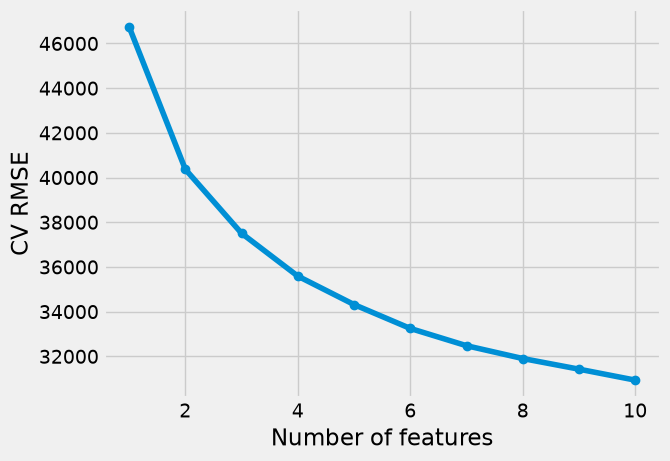

In [24]:
plt.plot(results_df['n_features'], results_df['cv_rmse'], marker='o')
plt.xlabel('Number of features')
plt.ylabel('CV RMSE')
plt.show()

The CV error drops quickly for the first few features and then decreases only slowly: each additional feature helps less and less, while the model gets more complex (bias-variance trade-off).

We choose the number of features with the lowest CV RMSE. The minimum is at the edge of our range, so more features would likely help further; we stop at 10 to keep the runtime short.

Fit the chosen model on the full training data and evaluate it once on the test set.

In [26]:
features_chosen = results_df.loc[results_df['n_features'] == k_chosen, 'features'].iloc[0]
print(features_chosen)

mod_chosen = LinearRegression().fit(X_train[features_chosen], y_train)
preds_chosen = mod_chosen.predict(X_test[features_chosen])
print(root_mean_squared_error(y_test, preds_chosen))

['OverallQual', 'GrLivArea', 'BsmtQual_Ex', 'BsmtFinSF1', 'YearBuilt', 'MSSubClass', 'KitchenQual_Ex', 'BsmtExposure_Gd', 'OverallCond', 'Neighborhood_NoRidge']
32965.608542826776


## Your turn!

**Your turn!** *Fewer vs. all features.* Fit a linear regression on **all** features of `X_train` and compare its test RMSE with the forward-selected model above. Which model is better, and why?

In [27]:
# YOUR CODE HERE

**Your turn!** *Business sense check.* Look at the selected features in the order they were added (`results_df`). Do they make sense for house prices? Add one feature you would expect to matter but that wasn't selected, refit the model, and compare the test RMSE. (Hint: `X_train.columns` lists all available features.)

In [28]:
# YOUR CODE HERE